In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("adult_with_headers (1).csv")
print(df.head())

   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0              40   United-States   <=50

In [22]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (32561, 15)


In [23]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


In [4]:
print(df.describe())

                age        fnlwgt  education_num  capital_gain  capital_loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours_per_week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [5]:
df.replace(" ?", np.nan, inplace=True)

In [6]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64


In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


#### Standard Scaling

In [10]:
df_standard = df.copy()

In [11]:
scaler = StandardScaler()
df_standard[num_cols] = scaler.fit_transform(df_standard[num_cols])
print(df_standard.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.030671          State-gov -1.063611   Bachelors       1.134739   
1  0.837109   Self-emp-not-inc -1.008707   Bachelors       1.134739   
2 -0.042642            Private  0.245079     HS-grad      -0.420060   
3  1.057047            Private  0.425801        11th      -1.197459   
4 -0.775768            Private  1.408176   Bachelors       1.134739   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0      0.148453      -0.21

#### Min-Max Scaling

In [12]:
df_minmax = df.copy()

In [13]:
minmax = MinMaxScaler()
df_minmax[num_cols] = minmax.fit_transform(df_minmax[num_cols])
print(df_minmax.head())

        age          workclass    fnlwgt   education  education_num  \
0  0.301370          State-gov  0.044302   Bachelors       0.800000   
1  0.452055   Self-emp-not-inc  0.048238   Bachelors       0.800000   
2  0.287671            Private  0.138113     HS-grad       0.533333   
3  0.493151            Private  0.151068        11th       0.400000   
4  0.150685            Private  0.221488   Bachelors       0.800000   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0       0.02174           

##### ●	Discuss the scenarios where each scaling technique is preferred and why.

In [ ]:
1. Standard Scaling

Definition:
Standard Scaling transforms numerical features so that they have a mean of 0 and a standard deviation of 1.

Preferred Scenarios:

Logistic Regression
Support Vector Machine (SVM)
K-Nearest Neighbors (KNN)
Principal Component Analysis (PCA)
Linear Regression

Why?

These algorithms are sensitive to the scale of input features.
It ensures that all numerical features contribute equally to the model.
It performs well when the data is approximately normally distributed.
It prevents features with larger values from dominating the learning process.

In [ ]:
2. Min-Max Scaling

Definition:
Min-Max Scaling transforms numerical features into a fixed range, usually 0 to 1.

Preferred Scenarios:

Neural Networks
Deep Learning Models
Gradient Descent-based algorithms
Image Processing

Why?

It scales all values to the same range (0–1).
It helps algorithms converge faster during training.
It preserves the relative relationships between the original values.
It is useful when algorithms require input values within a fixed range.

### 2. Encoding Techniques:

In [25]:
small_cat = [col for col in df.select_dtypes(include="object").columns
             if df[col].nunique() < 5]

df_onehot = pd.get_dummies(df, columns=small_cat)

print(df_onehot.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship    race  capital_gain  capital_loss  \
0           1             1   White          2174             0   
1           4             0   White             0             0   
2           6             1   White             0             0   
3           6             0   Black             0             0   
4          10             5   Black             0             0   

   hours_per_week  native_country  sex_ Female  sex_ Male  income_ <=50K  \
0              40              39        False       True           True   
1              13 

In [26]:
label = LabelEncoder()

large_cat = [col for col in df.select_dtypes(include="object").columns
             if df[col].nunique() > 5]

for col in large_cat:
    df[col] = label.fit_transform(df[col])

print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship    race      sex  capital_gain  capital_loss  \
0           1             1   White     Male          2174             0   
1           4             0   White     Male             0             0   
2           6             1   White     Male             0             0   
3           6             0   Black     Male             0             0   
4          10             5   Black   Female             0             0   

   hours_per_week  native_country  income  
0              40              39   <=50K  
1              13           

In [27]:
print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship    race      sex  capital_gain  capital_loss  \
0           1             1   White     Male          2174             0   
1           4             0   White     Male             0             0   
2           6             1   White     Male             0             0   
3           6             0   Black     Male             0             0   
4          10             5   Black   Female             0             0   

   hours_per_week  native_country  income  
0              40              39   <=50K  
1              13           

In [28]:
print(df.describe())

                age     workclass        fnlwgt     education  education_num  \
count  32561.000000  32561.000000  3.256100e+04  32561.000000   32561.000000   
mean      38.581647      3.868892  1.897784e+05     10.298210      10.080679   
std       13.640433      1.455960  1.055500e+05      3.870264       2.572720   
min       17.000000      0.000000  1.228500e+04      0.000000       1.000000   
25%       28.000000      4.000000  1.178270e+05      9.000000       9.000000   
50%       37.000000      4.000000  1.783560e+05     11.000000      10.000000   
75%       48.000000      4.000000  2.370510e+05     12.000000      12.000000   
max       90.000000      8.000000  1.484705e+06     15.000000      16.000000   

       marital_status    occupation  relationship  capital_gain  capital_loss  \
count    32561.000000  32561.000000  32561.000000  32561.000000  32561.000000   
mean         2.611836      6.572740      1.446362   1077.648844     87.303830   
std          1.506222      4.228857 

In [29]:
df.replace(" ?", np.nan, inplace=True)

print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


In [30]:
print(df.dtypes)

age                int64
workclass          int64
fnlwgt             int64
education          int64
education_num      int64
marital_status     int64
occupation         int64
relationship       int64
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country     int64
income            object
dtype: object


In [31]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    if df[col].nunique() > 5:
        df[col] = le.fit_transform(df[col])

print(df.head())

   age  workclass  fnlwgt  education  education_num  marital_status  \
0   39          7   77516          9             13               4   
1   50          6   83311          9             13               2   
2   38          4  215646         11              9               0   
3   53          4  234721          1              7               2   
4   28          4  338409          9             13               2   

   occupation  relationship    race      sex  capital_gain  capital_loss  \
0           1             1   White     Male          2174             0   
1           4             0   White     Male             0             0   
2           6             1   White     Male             0             0   
3           6             0   Black     Male             0             0   
4          10             5   Black   Female             0             0   

   hours_per_week  native_country  income  
0              40              39   <=50K  
1              13           

In [ ]:
Pros and Cons of One-Hot Encoding
Pros
Converts categorical data into numerical format.
Does not create any order or ranking between categories.
Works well for categorical variables with a small number of categories.
Improves the performance of many machine learning models.
Cons
Increases the number of columns in the dataset.
Can make the dataset large and sparse when there are many categories.
Increases memory usage and computational cost.

In [ ]:
Pros and Cons of Label Encoding
Pros
Simple and easy to implement.
Does not increase the number of columns.
Saves memory and computational time.
Suitable for categorical variables with many unique categories.
Cons
Assigns numerical values that may create a false order among categories.
Some machine learning algorithms may incorrectly interpret the encoded values as having a meaningful ranking.
May reduce model performance for nominal (unordered) categorical variables.

### 3. Feature Engineering:

In [32]:
df["Total_Capital"] = df["capital_gain"] - df["capital_loss"]
print(df[["capital_gain", "capital_loss", "Total_Capital"]].head())

   capital_gain  capital_loss  Total_Capital
0          2174             0           2174
1             0             0              0
2             0             0              0
3             0             0              0
4             0             0              0


In [33]:
df["Age_Group"] = pd.cut(df["age"],
                         bins=[0, 25, 45, 65, 100],
                         labels=["Young", "Adult", "Middle_Age", "Senior"])

print(df[["age", "Age_Group"]].head())

   age   Age_Group
0   39       Adult
1   50  Middle_Age
2   38       Adult
3   53  Middle_Age
4   28       Adult


In [34]:
df["capital_gain_log"] = np.log1p(df["capital_gain"])

print(df[["capital_gain", "capital_gain_log"]].head())

   capital_gain  capital_gain_log
0          2174          7.684784
1             0          0.000000
2             0          0.000000
3             0          0.000000
4             0          0.000000


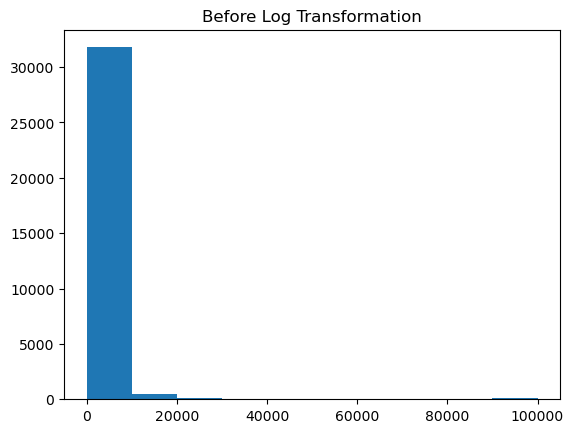

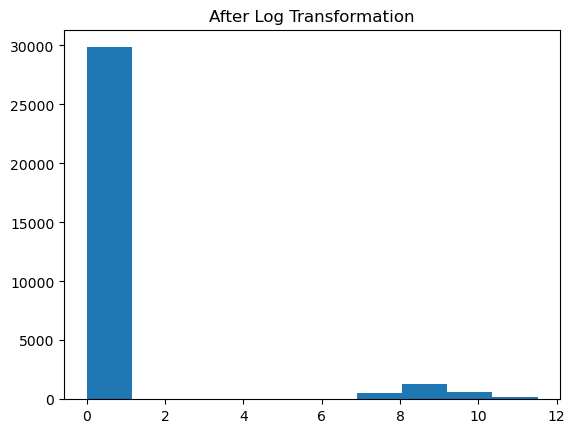

In [38]:
df["capital_gain_log"] = np.log1p(df["capital_gain"])
plt.hist(df["capital_gain"])
plt.title("Before Log Transformation")
plt.show()

plt.hist(df["capital_gain_log"])
plt.title("After Log Transformation")
plt.show()